# LightGBM — crash severity classification

Single-model baseline alongside the TabNet / Stacking / MLP / LR notebooks.
Same data, same seed, same split, same SMOTE rule, same Optuna config (50
trials, macro-F1 objective, 5-fold stratified CV), same threshold sweep, same
SHAP setup (KernelExplainer 100 bg / 200 eval / nsamples=100), same
Light_conditions sensitivity check. The only model-specific piece is the
LightGBM classifier.

## Pipeline

1. Load `data/data_cleaned.csv`, define feature set, train / val / test split.
2. OrdinalEncoder on categoricals (+1 shift, parity with the other notebooks).
   Trees do not need scaling; LightGBM consumes the ordinal codes directly.
3. Optuna search on LightGBM hyperparameters with 5-fold stratified CV. SMOTE
   on the training fold only.
4. Train final LightGBM on full SMOTE-resampled training set.
5. Test set evaluation: accuracy, precision, recall, F1, AUC, confusion matrix.
6. Per-class threshold tuning with line plots.
7. SHAP analysis (KernelExplainer) and a Light_conditions sensitivity study.
8. Save model and metrics.

Color convention: Fatal = red, Serious = yellow, Slight = green.

## 1. Setup

In [3]:

import json
import logging
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder
import optuna
import shap

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("lgbm")
logging.getLogger("shap").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd()
DATA = ROOT / "data" / "data_cleaned.csv"
MODEL_DIR = ROOT / "models"
FIG_DIR = ROOT / "outputs" / "figures"
RESULTS = ROOT / "outputs" / "lightgbm_metrics.json"
for p in (MODEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

N_TRIALS = 50
N_FOLDS = 5
SHAP_BG = 100
SHAP_EVAL = 200

SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {"Slight Injury": "#2ca02c", "Serious Injury": "#f1c40f", "Fatal injury": "#d62728"}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]
SEV_SHORT = ["Slight", "Serious", "Fatal"]


## 2. Helpers

`encode()` matches the encoder used in the Stacking notebook: OrdinalEncoder
with `-1` for unknowns, then a `+1` shift so unknowns occupy index 0. LightGBM
consumes the ordinal codes as float features (no need for scaling).

In [4]:

def define_features(df: pd.DataFrame):
    """Same feature contract as TabNet / Stacking / MLP / LR."""
    drop_originals_with_ord = [
        "Age_band_of_driver", "Driving_experience",
        "Service_year_of_vehicle", "Educational_level",
    ]
    target_cols = ["Accident_severity", "Severity_code"]
    cat_cols = [c for c in df.select_dtypes(include="object").columns
                if c not in target_cols + drop_originals_with_ord]
    num_cols = [c for c in df.select_dtypes(include=["int64", "float64"]).columns
                if c not in target_cols]
    return cat_cols, num_cols


def encode(df, cat_cols, num_cols, encoder=None, fit=True):
    """OrdinalEncoder + unknown-shift, then concatenate with raw numerics."""
    cat = df[cat_cols].astype(str).values
    num = df[num_cols].astype(float).values

    if fit:
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        cat_enc = encoder.fit_transform(cat)
    else:
        cat_enc = encoder.transform(cat)

    cat_enc = cat_enc + 1
    X = np.concatenate([cat_enc, num], axis=1).astype(np.float32)
    return X, encoder


def metric_block(y_true, y_pred, y_proba, label=""):
    out = {
        "accuracy":         accuracy_score(y_true, y_pred),
        "precision_macro":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":     recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr":      roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }
    print(f"=== {label} ===")
    for k, v in out.items():
        print(f"  {k:<18s} {v:.4f}")
    print("\n  classification report:")
    print(classification_report(y_true, y_pred, target_names=SEV_SHORT, zero_division=0))
    return out


def plot_confusion(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(SEV_SHORT); ax.set_yticklabels(SEV_SHORT)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


## 3. Load data and split

Identical split to the other notebooks (same seed, same proportions, same
stratification) so all models are directly comparable.

In [5]:

df = pd.read_csv(DATA)
cat_cols, num_cols = define_features(df)
feature_names = cat_cols + num_cols

log.info(f"data shape: {df.shape}")
log.info(f"cat features ({len(cat_cols)}): {cat_cols}")
log.info(f"num features ({len(num_cols)}): {num_cols}")

y = df["Severity_code"].values
print(pd.Series(y).map(dict(enumerate(SEV_SHORT))).value_counts())


20:01:14 [INFO] data shape: (12316, 32)
20:01:14 [INFO] cat features (17): ['Day_of_week', 'Sex_of_driver', 'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident', 'TimeOfDay']
20:01:14 [INFO] num features (9): ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'RushHour', 'IsWeekend', 'Age_band_of_driver_ord', 'Driving_experience_ord', 'Service_year_of_vehicle_ord', 'Educational_level_ord']


Slight     10415
Serious     1743
Fatal        158
Name: count, dtype: int64


In [6]:

df_trainval, df_test = train_test_split(
    df, test_size=0.15, stratify=y, random_state=SEED)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.1765,
    stratify=df_trainval["Severity_code"].values, random_state=SEED)

log.info(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

X_train, encoder = encode(df_train, cat_cols, num_cols, fit=True)
X_val, _ = encode(df_val, cat_cols, num_cols, encoder, fit=False)
X_test, _ = encode(df_test, cat_cols, num_cols, encoder, fit=False)
y_train = df_train["Severity_code"].values
y_val = df_val["Severity_code"].values
y_test = df_test["Severity_code"].values
log.info(f"feature dim: {X_train.shape[1]}")


20:01:14 [INFO] train=8620  val=1848  test=1848
20:01:14 [INFO] feature dim: 26


## 4. Optuna hyperparameter search

Tunes LightGBM with a 9-knob search space covering tree shape (num_leaves,
max_depth, min_child_samples), regularization (reg_alpha, reg_lambda),
sampling (subsample, colsample_bytree), and learning dynamics (n_estimators,
learning_rate). Bagging is enabled via `bagging_freq=1`.

Objective: macro-F1 — same as the other notebooks (Fatal class is rare).

In [7]:

def build_lgbm(params):
    return LGBMClassifier(
        objective="multiclass", num_class=3,
        random_state=SEED, n_jobs=-1, verbose=-1,
        bagging_freq=1,
        **params,
    )


class OptunaProgress:
    def __init__(self, total): self.total = total; self.t0 = time.time()

    def __call__(self, study, trial):
        elapsed = time.time() - self.t0
        avg = elapsed / (trial.number + 1)
        eta = avg * (self.total - trial.number - 1)
        log.info(f"trial {trial.number + 1:>2d}/{self.total} | "
                 f"value={trial.value:.4f} | best={study.best_value:.4f} | "
                 f"elapsed={elapsed:>6.1f}s | ETA={eta:>6.1f}s")


In [8]:

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.25, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 50),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
    )

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        sm = SMOTE(random_state=SEED, k_neighbors=5)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        model = build_lgbm(params)
        model.fit(X_tr_sm, y_tr_sm)
        preds = model.predict(X_va)
        fold_scores.append(f1_score(y_va, preds, average="macro"))
    return float(np.mean(fold_scores))


In [9]:

log.info(f"Starting Optuna search: {N_TRIALS} trials, {N_FOLDS}-fold CV")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[OptunaProgress(N_TRIALS)])
log.info(f"Optuna done in {time.time() - t0:.1f}s")
log.info(f"best macro-F1: {study.best_value:.4f}")
log.info(f"best params: {study.best_params}")

best_params = dict(study.best_params)


20:01:14 [INFO] Starting Optuna search: 50 trials, 5-fold CV
20:01:34 [INFO] trial  1/50 | value=0.4243 | best=0.4243 | elapsed=  19.7s | ETA= 965.0s
20:02:39 [INFO] trial  2/50 | value=0.4233 | best=0.4243 | elapsed=  85.1s | ETA=2041.7s
20:02:45 [INFO] trial  3/50 | value=0.3949 | best=0.4243 | elapsed=  91.1s | ETA=1427.6s
20:02:55 [INFO] trial  4/50 | value=0.4082 | best=0.4243 | elapsed= 101.0s | ETA=1161.7s
20:03:13 [INFO] trial  5/50 | value=0.4140 | best=0.4243 | elapsed= 118.4s | ETA=1065.7s
20:03:38 [INFO] trial  6/50 | value=0.4179 | best=0.4243 | elapsed= 143.8s | ETA=1054.4s
20:03:46 [INFO] trial  7/50 | value=0.4251 | best=0.4251 | elapsed= 151.5s | ETA= 930.9s
20:03:51 [INFO] trial  8/50 | value=0.3936 | best=0.4251 | elapsed= 156.9s | ETA= 824.0s
20:04:01 [INFO] trial  9/50 | value=0.4051 | best=0.4251 | elapsed= 166.6s | ETA= 758.9s
20:04:12 [INFO] trial 10/50 | value=0.4014 | best=0.4251 | elapsed= 177.4s | ETA= 709.7s
20:04:17 [INFO] trial 11/50 | value=0.4052 | best

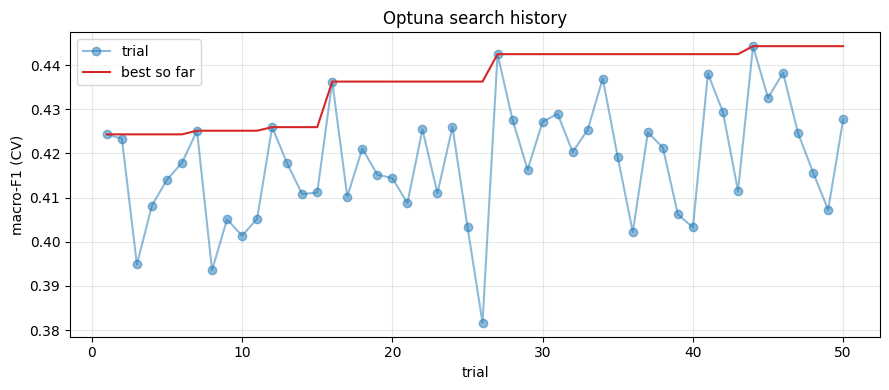

In [10]:

trial_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(trial_vals) + 1), trial_vals, "o-", alpha=0.5, label="trial")
ax.plot(range(1, len(running_best) + 1), running_best, "-", color="#d62728", label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("macro-F1 (CV)")
ax.set_title("Optuna search history")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "lightgbm_optuna_history.png", dpi=150)
plt.show()


## 5. Train final LightGBM

In [11]:

log.info("SMOTE on full training set ...")
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
log.info(f"SMOTE: {len(y_train)} -> {len(y_train_sm)}")
log.info(f"class counts after SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().tolist()}")

final_model = build_lgbm(best_params)
t0 = time.time()
final_model.fit(X_train_sm, y_train_sm)
log.info(f"final fit in {time.time() - t0:.1f}s")


20:12:26 [INFO] SMOTE on full training set ...
20:12:26 [INFO] SMOTE: 8620 -> 21867
20:12:26 [INFO] class counts after SMOTE: [7289, 7289, 7289]
20:12:30 [INFO] final fit in 4.0s


In [12]:

# Quick validation-set sanity check before going to the held-out test set.
val_pred = final_model.predict(X_val)
val_proba = final_model.predict_proba(X_val)
_ = metric_block(y_val, val_pred, val_proba, label="Validation set")


=== Validation set ===
  accuracy           0.8409
  precision_macro    0.5490
  recall_macro       0.3992
  f1_macro           0.4218
  f1_weighted        0.8040
  roc_auc_ovr        0.7200

  classification report:
              precision    recall  f1-score   support

      Slight       0.86      0.97      0.91      1563
     Serious       0.45      0.15      0.22       261
       Fatal       0.33      0.08      0.13        24

    accuracy                           0.84      1848
   macro avg       0.55      0.40      0.42      1848
weighted avg       0.80      0.84      0.80      1848



## 6. Test set evaluation

=== Test set (argmax) ===
  accuracy           0.8474
  precision_macro    0.7033
  recall_macro       0.4218
  f1_macro           0.4604
  f1_weighted        0.8127
  roc_auc_ovr        0.7279

  classification report:
              precision    recall  f1-score   support

      Slight       0.87      0.97      0.92      1563
     Serious       0.49      0.17      0.25       261
       Fatal       0.75      0.12      0.21        24

    accuracy                           0.85      1848
   macro avg       0.70      0.42      0.46      1848
weighted avg       0.81      0.85      0.81      1848



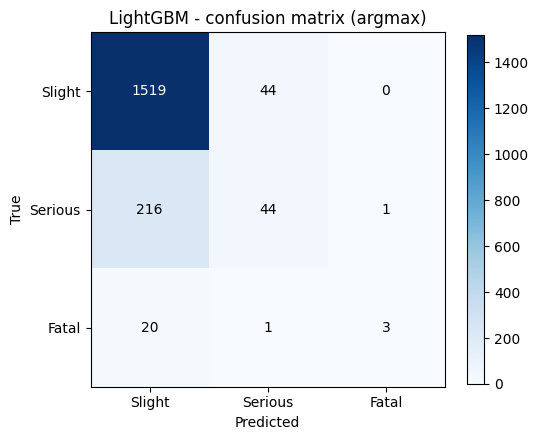

In [13]:

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_metrics = metric_block(y_test, y_pred, y_proba, label="Test set (argmax)")
cm = confusion_matrix(y_test, y_pred)
plot_confusion(cm, "LightGBM - confusion matrix (argmax)",
               save_path=FIG_DIR / "lightgbm_confusion_argmax.png")


## 7. Per-class threshold tuning

Same approach as the other notebooks: sweep one-vs-rest thresholds and pick
the per-class F1 maximum.

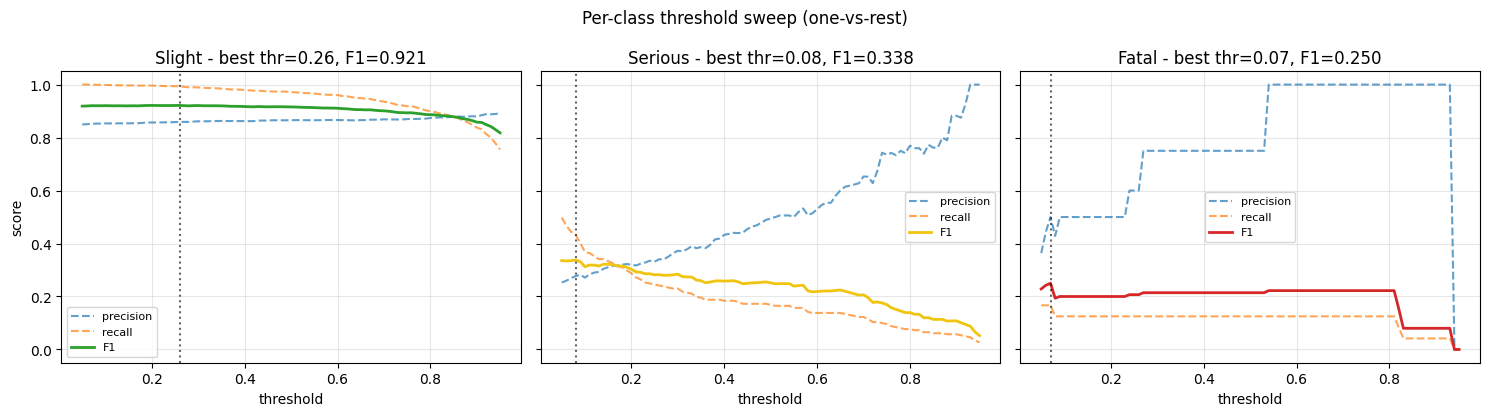

Best per-class thresholds: {'Slight': 0.25999999999999995, 'Serious': 0.08, 'Fatal': 0.07}


In [14]:

thresholds = np.linspace(0.05, 0.95, 91)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
best_thr = {}

for k, (name, color) in enumerate(zip(SEV_SHORT, SEVERITY_PALETTE)):
    f1s, pres, recs = [], [], []
    y_bin = (y_test == k).astype(int)
    for thr in thresholds:
        p_bin = (y_proba[:, k] >= thr).astype(int)
        f1s.append(f1_score(y_bin, p_bin, zero_division=0))
        pres.append(precision_score(y_bin, p_bin, zero_division=0))
        recs.append(recall_score(y_bin, p_bin, zero_division=0))

    f1s = np.array(f1s); pres = np.array(pres); recs = np.array(recs)
    best_idx = int(np.argmax(f1s))
    best_thr[name] = float(thresholds[best_idx])

    ax = axes[k]
    ax.plot(thresholds, pres, label="precision", color="#1f77b4", linestyle="--", alpha=0.7)
    ax.plot(thresholds, recs, label="recall",    color="#ff7f0e", linestyle="--", alpha=0.7)
    ax.plot(thresholds, f1s,  label="F1",        color=color, linewidth=2)
    ax.axvline(thresholds[best_idx], color="black", linestyle=":", alpha=0.6)
    ax.set_title(f"{name} - best thr={thresholds[best_idx]:.2f}, F1={f1s[best_idx]:.3f}")
    ax.set_xlabel("threshold")
    if k == 0: ax.set_ylabel("score")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-class threshold sweep (one-vs-rest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "lightgbm_threshold_sweep.png", dpi=150)
plt.show()
print("Best per-class thresholds:", best_thr)


=== Test set (threshold-tuned) ===
  accuracy           0.8474
  precision_macro    0.7033
  recall_macro       0.4218
  f1_macro           0.4604
  f1_weighted        0.8127
  roc_auc_ovr        0.7279

  classification report:
              precision    recall  f1-score   support

      Slight       0.87      0.97      0.92      1563
     Serious       0.49      0.17      0.25       261
       Fatal       0.75      0.12      0.21        24

    accuracy                           0.85      1848
   macro avg       0.70      0.42      0.46      1848
weighted avg       0.81      0.85      0.81      1848



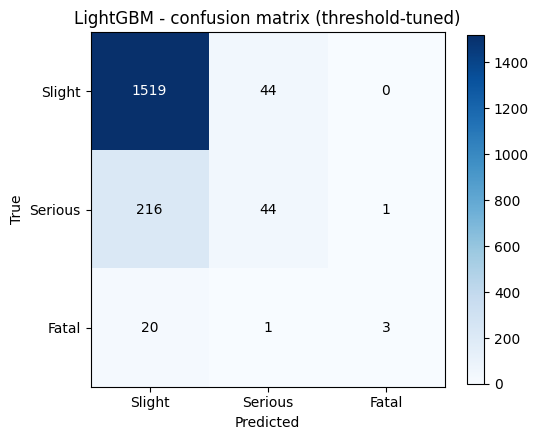

In [15]:

def predict_with_thresholds(proba, thr_map):
    thr_arr = np.array([thr_map[n] for n in SEV_SHORT])
    above = proba >= thr_arr
    out = np.full(len(proba), -1, dtype=int)
    for i in range(len(proba)):
        if above[i].any():
            cand = np.where(above[i])[0]
            out[i] = cand[np.argmax(proba[i, cand])]
        else:
            out[i] = int(np.argmax(proba[i]))
    return out


y_pred_tuned = predict_with_thresholds(y_proba, best_thr)
tuned_metrics = metric_block(y_test, y_pred_tuned, y_proba,
                             label="Test set (threshold-tuned)")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plot_confusion(cm_tuned, "LightGBM - confusion matrix (threshold-tuned)",
               save_path=FIG_DIR / "lightgbm_confusion_tuned.png")


## 8. Save model and metrics

In [16]:

save_path = MODEL_DIR / "lightgbm_best.joblib"
joblib.dump({
    "model": final_model,
    "encoder": encoder,
    "cat_cols": cat_cols, "num_cols": num_cols,
    "feature_names": feature_names,
    "best_params": best_params,
    "best_thresholds": best_thr,
}, save_path)

results = {
    "best_params": best_params,
    "best_thresholds": best_thr,
    "test_argmax": test_metrics,
    "test_threshold_tuned": tuned_metrics,
    "confusion_argmax": cm.tolist(),
    "confusion_tuned": cm_tuned.tolist(),
    "n_train": int(len(y_train)), "n_val": int(len(y_val)), "n_test": int(len(y_test)),
}
RESULTS.write_text(json.dumps(results, indent=2))
log.info(f"Saved model to {save_path}")
log.info(f"Wrote {RESULTS}")


20:12:32 [INFO] Saved model to /home/thsondev/Projects/crash-severity-tabnet-stacking/models/lightgbm_best.joblib
20:12:32 [INFO] Wrote /home/thsondev/Projects/crash-severity-tabnet-stacking/outputs/lightgbm_metrics.json


## 9. SHAP interpretation

KernelExplainer on the LightGBM model's `predict_proba`. Background and eval
sizes match the other notebooks for cross-model parity. (LightGBM also supports
the faster `shap.TreeExplainer`, but KernelExplainer is the shared contract.)

In [18]:

rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train_sm), size=min(SHAP_BG, len(X_train_sm)), replace=False)
background = X_train_sm[bg_idx]

eval_idx = rng.choice(len(X_test), size=min(SHAP_EVAL, len(X_test)), replace=False)
X_shap = X_test[eval_idx]

log.info(f"SHAP: background={len(background)}, eval={len(X_shap)}")
explainer = shap.KernelExplainer(
      lambda x: final_model.predict_proba(x),
      background
  )
t0 = time.time()
shap_values = explainer.shap_values(X_shap, nsamples=100)
log.info(f"SHAP done in {time.time() - t0:.1f}s; shape={np.array(shap_values).shape}")


20:40:40 [INFO] SHAP: background=100, eval=200
100%|██████████| 200/200 [00:18<00:00, 10.94it/s]
20:40:58 [INFO] SHAP done in 18.3s; shape=(200, 26, 3)


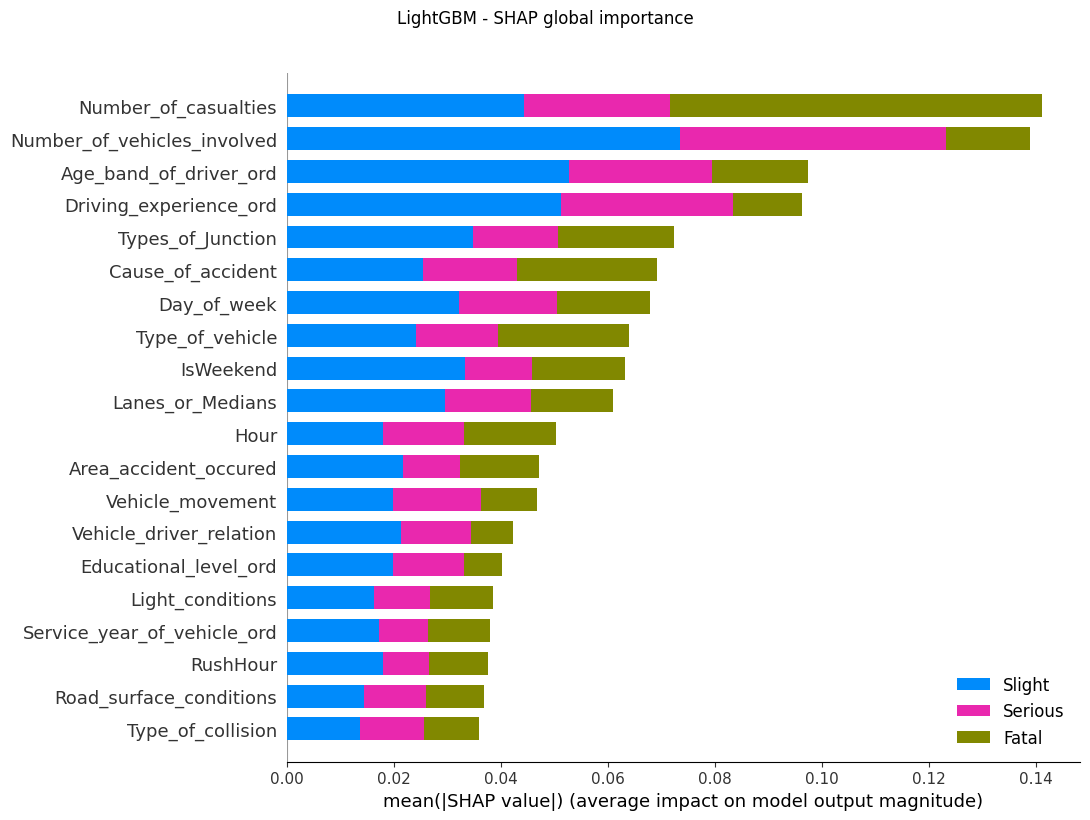

In [19]:

# Convert SHAP output to a per-class list of (N, F) arrays, then global bar plot.
if isinstance(shap_values, list):
    shap_per_class = shap_values
else:
    shap_per_class = [shap_values[:, :, k] for k in range(3)]

shap.summary_plot(shap_per_class, X_shap, feature_names=feature_names,
                  plot_type="bar", class_names=SEV_SHORT, show=False, plot_size=(11, 8))
fig = plt.gcf(); fig.suptitle("LightGBM - SHAP global importance", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "lightgbm_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()


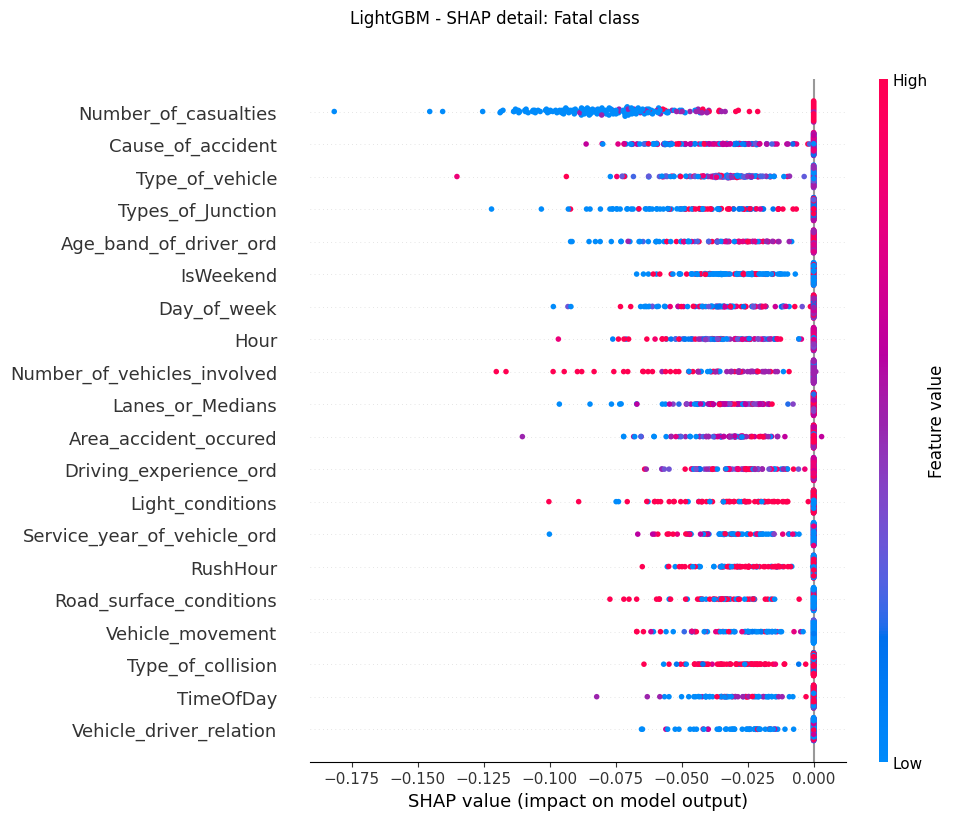

In [20]:

fatal_idx = SEV_SHORT.index("Fatal")
shap.summary_plot(shap_per_class[fatal_idx], X_shap, feature_names=feature_names,
                  plot_type="dot", show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.suptitle("LightGBM - SHAP detail: Fatal class", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "lightgbm_shap_dot_fatal.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Post-hoc / sensitivity analysis

Same intervention as the other notebooks: set `Light_conditions` to 'Daylight'
across the test set and compare mean predicted probabilities.

Mean predicted probability shift after setting Light_conditions='Daylight':
  Slight   original=0.9146  intervened=0.9132  delta=-0.0014
  Serious  original=0.0831  intervened=0.0849  delta=+0.0018
  Fatal    original=0.0023  intervened=0.0019  delta=-0.0004


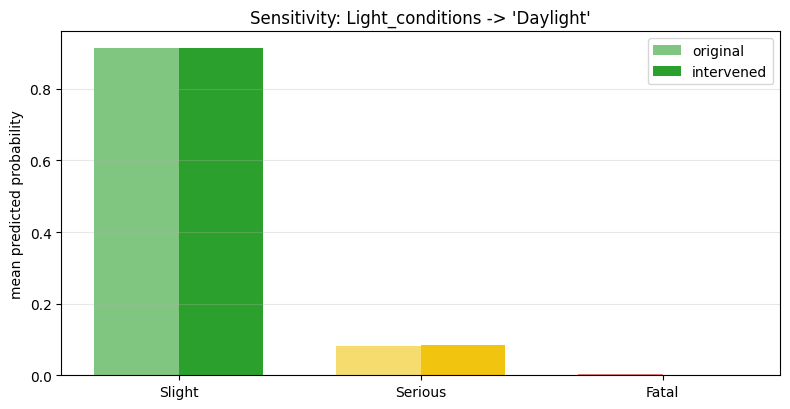

In [21]:

target_feature = "Light_conditions"
intervene_value = "Daylight"

if intervene_value not in df["Light_conditions"].unique():
    intervene_value = df["Light_conditions"].mode().iloc[0]
    log.info(f"'Daylight' not in data; intervening with '{intervene_value}' instead")

df_test_int = df_test.copy()
df_test_int[target_feature] = intervene_value
X_test_int, _ = encode(df_test_int, cat_cols, num_cols, encoder, fit=False)
proba_int = final_model.predict_proba(X_test_int)

orig_mean = y_proba.mean(axis=0)
intv_mean = proba_int.mean(axis=0)
delta = intv_mean - orig_mean

print(f"Mean predicted probability shift after setting {target_feature}='{intervene_value}':")
for name, o, i, d in zip(SEV_SHORT, orig_mean, intv_mean, delta):
    print(f"  {name:<8s} original={o:.4f}  intervened={i:.4f}  delta={d:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, orig_mean, width=w, color=SEVERITY_PALETTE, label="original", alpha=0.6)
ax.bar(x + w/2, intv_mean, width=w, color=SEVERITY_PALETTE, label="intervened", alpha=1.0)
ax.set_xticks(x); ax.set_xticklabels(SEV_SHORT)
ax.set_ylabel("mean predicted probability")
ax.set_title(f"Sensitivity: {target_feature} -> '{intervene_value}'")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "lightgbm_sensitivity_light.png", dpi=150)
plt.show()


## 11. Summary

- Best Optuna macro-F1 (CV): see log above.
- Argmax test metrics + threshold-tuned test metrics reported.
- Saved artefacts: `models/lightgbm_best.joblib`, `outputs/lightgbm_metrics.json`,
  and figures under `outputs/figures/lightgbm_*.png`.

Run alongside `tabnet.ipynb`, `stacking-ensemble.ipynb`, `mlp.ipynb`, and
`lr.ipynb` for direct comparison - all five notebooks share the same
train/val/test split (same seed, same proportions) and the same feature contract.